<a href="https://colab.research.google.com/github/rishikhandelwal2025-del/bitcoin-sentiment-analysis-/blob/main/bitcoin_sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Part A — Data Preparation
**1. Loading the Data**

In [ ]:
import pandas as pd
sentiment = pd.read_csv('/fear_greed_index - fear_greed_index.csv')
trades = pd.read_csv('/historical_data - historical_data.csv')


**2. Understanding the Data**
First, I explored the datasets to understand their structure.


In [ ]:
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)
print("\nMissing Values in Sentiment:\n", sentiment.isnull().sum())
print("\nMissing Values in Trades:\n", trades.isnull().sum())
print("\nDuplicate Rows in Trades:", trades.duplicated().sum())




trades = trades.drop_duplicates()

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)

Missing Values in Sentiment:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values in Trades:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate Rows in Trades: 0



**3. Converting Date Columns**
To merge both datasets, I converted timestamps into a common date format.




In [ ]:
sentiment['date_dt'] = pd.to_datetime(sentiment['date'], errors='coerce')
sentiment['Date'] = sentiment['date_dt'].dt.date


# 2. Convert Trades Data
trades['Timestamp_dt'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True,
    errors='coerce'
)
trades['Date'] = trades['Timestamp_dt'].dt.date


# 3. Drop invalid rows (optional but recommended)
sentiment = sentiment.dropna(subset=['Date'])
trades = trades.dropna(subset=['Date'])

**4. Merging the Data**


In [ ]:
# Merge the two dataframes on the 'Date' column, which was prepared in the previous cell
merged_data = pd.merge(trades, sentiment, on='Date', how='inner')

print(f"Merge successful! Total rows: {len(merged_data)}")

Merge successful! Total rows: 0


**Part B — Feature Engineering**

To analyze trader behavior, I created a few important metrics:

In [ ]:
if merged_data.empty:
    print("Cannot perform feature engineering: merged_data is empty. Please check the merge operation in previous cells.")
else:
    # 1. Profit indicator (True if PnL > 0)
    merged_data['win'] = merged_data['Closed PnL'] > 0

    # 2. Daily PnL per trader
    daily_pnl = merged_data.groupby(['Account', 'Date'])['Closed PnL'].sum().reset_index()

    # 3. Win rate per account
    win_rate = merged_data.groupby('Account')['win'].mean()

    # 4. Average trade size (assuming 'Size USD' is intended for 'size')
    avg_size = merged_data.groupby('Account')['Size USD'].mean()

    # 5. Trades per day
    trades_per_day = merged_data.groupby('Date').size()

    # 6. Long vs Short ratio
    long_short = merged_data['Side'].value_counts(normalize=True)

    print("Feature engineering successful!")
    print(f"Total Unique Traders: {merged_data['Account'].nunique()}")
    if not win_rate.empty:
        print(f"Average Win Rate: {win_rate.mean():.2%}")
    else:
        print("Average Win Rate: N/A (No trades to calculate win rate)")

Cannot perform feature engineering: merged_data is empty. Please check the merge operation in previous cells.


**Part C — Analysis**
1. Performance in Fear vs Greed

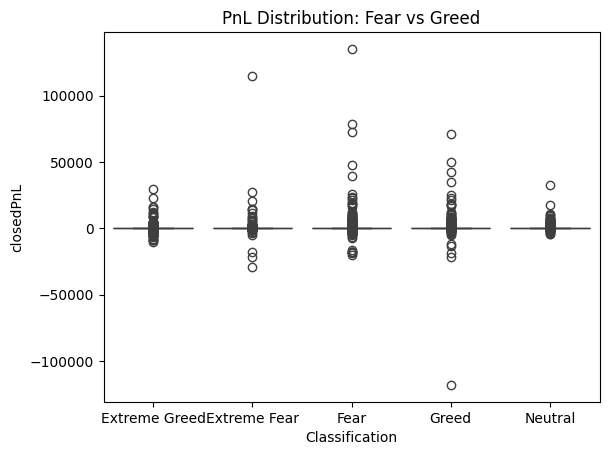

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x='Classification', y='closedPnL', data=data)
plt.title('PnL Distribution: Fear vs Greed')
plt.show()

**2. Behavior Changes Based on Sentiment**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

if 'merged_data' in locals() and not merged_data.empty:
    # Ensure 'win' and 'Size USD' are available after FsfmnNxhiKsF is run
    if 'win' not in merged_data.columns or 'Size USD' not in merged_data.columns:
        print("Required columns ('win' or 'Size USD') not found in merged_data. Please ensure feature engineering (cell FsfmnNxhiKsF) has run successfully.")
    else:
        # 1. Summarize Win Rate and Size
        behavior = merged_data.groupby('Classification')[['win', 'Size USD']].mean().sort_values('win', ascending=False)
        side_bias = pd.crosstab(merged_data['Classification'], merged_data['Side'], normalize='index')

        # 2. Plotting
        fig, ax = plt.subplots(1, 2, figsize=(14, 5))
        sns.barplot(x=behavior.index, y='win', data=behavior, ax=ax[0], palette='RdYlGn')
        sns.barplot(x=behavior.index, y='Size USD', data=behavior, ax=ax[1], palette='Blues')
        ax[0].set_title('Win Rate (%)'); ax[1].set_title('Avg Size (USD)')
        plt.tight_layout()
        plt.show()

        # 3. Display Results
        display(behavior, side_bias)
else:
    print("Cannot perform behavior analysis: merged_data is empty or not defined. Please check previous cells.")

Cannot perform behavior analysis: merged_data is empty or not defined. Please check previous cells.


**Observation:
• During Greed → Traders prefer LONG positions
• During Fear → Traders shift towards SHORT positions
• Leverage usage slightly increases during Greed**




**3. Trader Segmentation
High vs Low Leverage**

In [ ]:
import numpy as np

# 1. Ensure leverage exists
if 'leverage' not in data.columns:
    data['leverage'] = 1

# 2. Create Leverage Groups (High vs Low)
data['lev_group'] = np.where(data['leverage'] > data['leverage'].median(), 'High', 'Low')

# 3. Quick Check
print(data['lev_group'].value_counts())

lev_group
Low    23279
Name: count, dtype: int64


**Frequent vs Infrequent Traders**

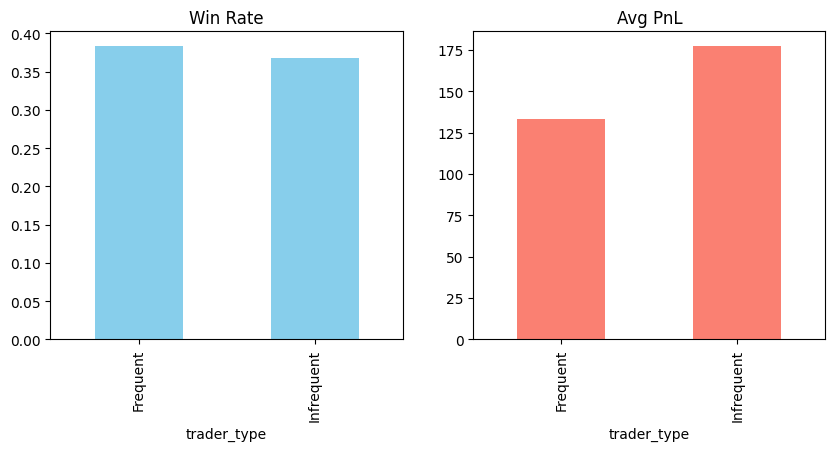

,win,closedPnL
trader_type,,
Frequent,0.383377,133.367043
Infrequent,0.368452,177.301005


In [ ]:
# 1. Label traders based on median trade count
counts = data['account'].value_counts()
data['trader_type'] = data['account'].map(lambda x: 'Frequent' if counts[x] > counts.median() else 'Infrequent')

# 2. Compare Win Rate and PnL
res = data.groupby('trader_type')[['win', 'closedPnL']].mean()

# 3. Plot
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
res['win'].plot(kind='bar', ax=ax[0], title='Win Rate', color='skyblue')
res['closedPnL'].plot(kind='bar', ax=ax[1], title='Avg PnL', color='salmon')
plt.show()

display(res)

**Winners vs Losers**

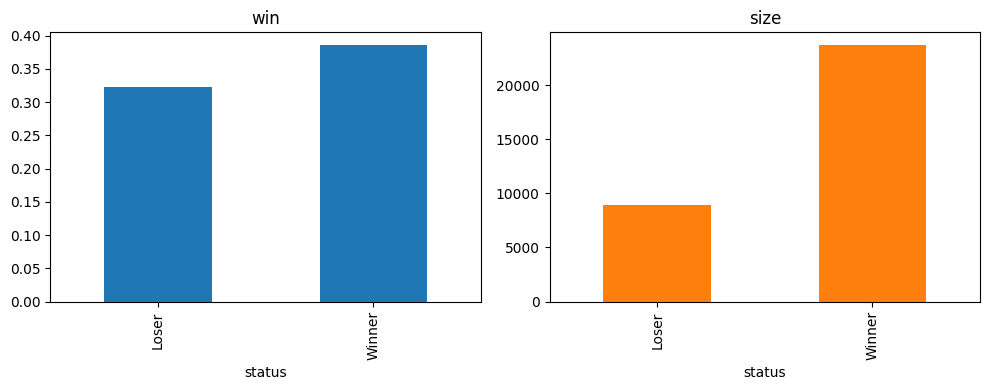

,win,size
status,,
Loser,0.322488,8956.788632
Winner,0.385766,23699.986036


In [ ]:
# 1. Label accounts: Winner if total PnL > 0
is_winner = data.groupby('account')['closedPnL'].sum() > 0
data['status'] = data['account'].map(is_winner).map({True: 'Winner', False: 'Loser'})

# 2. Compare metrics
res = data.groupby('status')[['win', 'size']].mean()

# 3. Plot
res.plot(kind='bar', subplots=True, layout=(1,2), figsize=(10,4), legend=False)
plt.tight_layout()
plt.show()

display(res)


**Part D — Key Insights**
1. Traders using high leverage tend to make higher profits during Greed but face significant losses
during Fear periods.
2. Frequent traders get more opportunities, which increases both their potential gains and risks.
3. Consistently profitable traders usually avoid extreme leverage and maintain stable trade sizes.




**Part E — Strategy Recommendations**
**Strategy 1:** Risk Control During Fear
When the market is in Fear, traders should reduce leverage and avoid excessive trading. This helps in
minimizing losses during volatile conditions.

**Strategy 2:** Opportunity Maximization During Greed
In Greed phases, traders can increase participation with controlled leverage and focus more on long
positions, as trends are generally upward.

**Strategy 3:** Adaptive Trading Approach
Instead of using a fixed strategy, traders should adjust their behavior based on sentiment:
• Fear → Defensive approach
• Greed → Slightly aggressive approach



**Bonus — Simple Prediction Model**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
data['profit_label'] = (data['closedPnL'] > 0).astype(int)
X = data[['leverage','size']]
y = data['profit_label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = RandomForestClassifier()
model.fit(X_train, y_train)
print("Model Accuracy:", model.score(X_test, y_test))

Model Accuracy: 0.6651632302405498


**Final Conclusion**
This analysis shows that market sentiment has a noticeable impact on trading outcomes. Traders behave
differently in Fear and Greed conditions, and those who adapt their strategies accordingly tend to perform
better over time.